In [10]:
# ============================================================
# Cell 1 — Imports
# Strategy D: Fine-tuning Strategy A (Color model) on Segmented data
# Goal: teach the best color model to also recognise texture patterns
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("✅ All imports successful!")
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {tf.config.list_physical_devices('GPU')}")

✅ All imports successful!
TensorFlow version : 2.21.0
GPU available      : []


In [11]:
# ============================================================
# Cell 2 — Paths & Configuration
# Strategy D loads Strategy A's saved model, then fine-tunes
# it using segmented images at a very small learning rate.
#
# Why lr = 1e-5?
#   Strategy A already has good weights. A large lr would
#   overwrite ("catastrophically forget") what it learned
#   from color images. 1e-5 makes tiny, careful adjustments.
#
# Why only 10 epochs?
#   Fine-tuning converges fast. Too many epochs = overfitting
#   to the segmented domain and losing color domain knowledge.
# ============================================================

# Fine-tuning data: segmented images (Strategy B's dataset)
FINETUNE_PATH = r"D:\Development\8th Sem Project\TomatoClassification\dataset\processed_segmented"

# Path to the saved Strategy A model
# Check your models folder — it may be 'tomato_classifier_final.h5' or 'best_model.h5'
MODEL_A_PATH  = r"D:\Development\8th Sem Project\TomatoClassification\models\tomato_classifier_final.h5"

MODEL_PATH    = r"D:\Development\8th Sem Project\TomatoClassification\models"
OUTPUT_PATH   = r"D:\Development\8th Sem Project\TomatoClassification\outputs"

IMAGE_SIZE      = (224, 224)
BATCH_SIZE      = 32
NUM_CLASSES     = 10
FINETUNE_LR     = 1e-5     # very small — preserves color knowledge from Strategy A
FINETUNE_EPOCHS = 10       # fine-tuning converges faster than full training
STRATEGY        = "D_finetuned"

os.makedirs(MODEL_PATH,  exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f"✅ Strategy           : {STRATEGY}")
print(f"📂 Base model (A)     : {MODEL_A_PATH}")
print(f"📁 Fine-tune dataset  : {FINETUNE_PATH}  (segmented)")
print(f"🔢 Learning rate      : {FINETUNE_LR}")
print(f"🔁 Fine-tune epochs   : {FINETUNE_EPOCHS}")

✅ Strategy           : D_finetuned
📂 Base model (A)     : D:\Development\8th Sem Project\TomatoClassification\models\tomato_classifier_final.h5
📁 Fine-tune dataset  : D:\Development\8th Sem Project\TomatoClassification\dataset\processed_segmented  (segmented)
🔢 Learning rate      : 1e-05
🔁 Fine-tune epochs   : 10


In [4]:
# ============================================================
# Cell 3 — Data Generators
# Loading the SEGMENTED dataset for fine-tuning.
# Augmentation is kept lighter than full training — fine-tuning
# data should be clean to avoid destabilizing pretrained weights.
# ============================================================

# Training augmentation — kept mild intentionally for fine-tuning
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,       # reduced from 15 — less aggressive
    horizontal_flip=True,
    zoom_range=0.08,         # reduced from 0.1
    width_shift_range=0.08,
    height_shift_range=0.08
)

# Validation & test — only rescale, no augmentation
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(FINETUNE_PATH, 'train'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(FINETUNE_PATH, 'val'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(FINETUNE_PATH, 'test'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"✅ Segmented data loaded for fine-tuning!")
print(f"🏋️  Training   : {train_generator.samples} images")
print(f"✔️  Validation : {val_generator.samples} images")
print(f"🧪 Test       : {test_generator.samples} images")
print(f"\n📋 Classes: {list(train_generator.class_indices.keys())}")

Found 6527 images belonging to 10 classes.
Found 1399 images belonging to 10 classes.
Found 1399 images belonging to 10 classes.
✅ Segmented data loaded for fine-tuning!
🏋️  Training   : 6527 images
✔️  Validation : 1399 images
🧪 Test       : 1399 images

📋 Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [5]:
# ============================================================
# Cell 4 — Load Strategy A Model & Prepare for Fine-tuning
#
# Fine-tuning strategy used here: PARTIAL UNFREEZING
#   We unfreeze only the LAST 30 layers of MobileNetV2.
#   MobileNetV2 has ~155 layers:
#     Layers 0-124  → FROZEN  (low-level: edges, corners — universal features)
#     Layers 125+   → TRAINABLE (high-level: disease-specific patterns)
#
#   BatchNorm layers are kept FROZEN even in the unfrozen region.
#   Reason: their running mean/variance was calibrated on color
#   images — updating them on segmented images causes instability.
# ============================================================

print(f"📂 Loading Strategy A model...\n")
model = load_model(MODEL_A_PATH)

print(f"✅ Strategy A model loaded!")
print(f"📊 Total layers : {len(model.layers)}")
print(f"📊 Input shape  : {model.input_shape}")
print(f"📊 Output shape : {model.output_shape}")

# Find the MobileNetV2 base layer inside the loaded model
base_model = None
for layer in model.layers:
    if 'mobilenetv2' in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    # Fallback if MobileNetV2 is not a nested sub-model
    print("⚠️  MobileNetV2 not found as sub-model — using index-based unfreezing.")
    for layer in model.layers:
        layer.trainable = False
    # Unfreeze last 30 layers of the whole model (covers high-level base + head)
    for layer in model.layers[-33:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True
else:
    print(f"\n✅ Found base model: {base_model.name}")
    print(f"   Total base layers: {len(base_model.layers)}")

    # Enable the base model for selective unfreezing
    base_model.trainable = True

    # Freeze all layers in the base first
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze only the last 30 (high-level feature layers)
    UNFREEZE_FROM = len(base_model.layers) - 30
    for layer in base_model.layers[UNFREEZE_FROM:]:
        # Skip BatchNorm — keep its statistics stable
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True

# Count trainable vs frozen parameters
trainable_params   = sum(tf.size(w).numpy() for w in model.trainable_weights)
untrainable_params = sum(tf.size(w).numpy() for w in model.non_trainable_weights)
print(f"\n🔓 Trainable params : {trainable_params:,}")
print(f"🔒 Frozen params    : {untrainable_params:,}")

# Recompile with fine-tuning lr
# IMPORTANT: always recompile after changing trainable layers
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n✅ Model ready for fine-tuning at lr = {FINETUNE_LR}")

📂 Loading Strategy A model...



✅ Strategy A model loaded!
📊 Total layers : 158
📊 Input shape  : (None, 224, 224, 3)
📊 Output shape : (None, 10)
⚠️  MobileNetV2 not found as sub-model — using index-based unfreezing.

🔓 Trainable params : 1,675,978
🔒 Frozen params    : 747,264

✅ Model ready for fine-tuning at lr = 1e-05


In [6]:
# ============================================================
# Cell 5 — Fine-tune the Model
#
# Callbacks tuned for fine-tuning:
#   EarlyStopping    patience=5  (same as full training)
#   ReduceLROnPlateau patience=2 (tighter — fine-tuning lr range
#                                 is very small, reduce faster)
#   ModelCheckpoint  same as before
# ============================================================

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_PATH, f'best_model_{STRATEGY}.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # patience=2 (tighter than training) — at lr=1e-5 any stall
    # means we are near the minimum, reduce immediately
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

print(f"🚀 Starting Fine-tuning — Strategy {STRATEGY}...")
print(f"   Base model : Strategy A (Color, 89.06%)")
print(f"   Fine-tune  : Segmented dataset")
print(f"   LR         : {FINETUNE_LR}\n")

history_ft = model.fit(
    train_generator,
    epochs=FINETUNE_EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks
)

print(f"\n✅ Fine-tuning Complete — Strategy {STRATEGY}!")
print(f"📊 Best Val Accuracy : {max(history_ft.history['val_accuracy']):.2%}")

🚀 Starting Fine-tuning — Strategy D_finetuned...
   Base model : Strategy A (Color, 89.06%)
   Fine-tune  : Segmented dataset
   LR         : 1e-05

Epoch 1/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 980ms/step - accuracy: 0.7450 - loss: 0.7878
Epoch 1: val_accuracy improved from None to 0.82202, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_D_finetuned.h5



Epoch 1: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_D_finetuned.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.7801 - loss: 0.6485 - val_accuracy: 0.8220 - val_loss: 0.5157 - learning_rate: 1.0000e-05
Epoch 2/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - accuracy: 0.8410 - loss: 0.4659
Epoch 2: val_accuracy improved from 0.82202 to 0.84060, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_D_finetuned.h5



Epoch 2: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_D_finetuned.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 181s 887ms/step - accuracy: 0.8460 - loss: 0.4531 - val_accuracy: 0.8406 - val_loss: 0.4707 - learning_rate: 1.0000e-05
Epoch 3/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 759ms/step - accuracy: 0.8610 - loss: 0.4094
Epoch 3: val_accuracy did not improve from 0.84060
204/204 ━━━━━━━━━━━━━━━━━━━━ 181s 888ms/step - accuracy: 0.8662 - loss: 0.3930 - val_accuracy: 0.8256 - val_loss: 0.5067 - learning_rate: 1.0000e-05
Epoch 4/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.8825 - loss: 0.3429
Epoch 4: val_accuracy improved from 0.84060 to 0.84989, saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_D_finetuned.h5



Epoch 4: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_D_finetuned.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 179s 879ms/step - accuracy: 0.8738 - loss: 0.3569 - val_accuracy: 0.8499 - val_loss: 0.4382 - learning_rate: 1.0000e-05
Epoch 5/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 757ms/step - accuracy: 0.8881 - loss: 0.3123
Epoch 5: val_accuracy did not improve from 0.84989
204/204 ━━━━━━━━━━━━━━━━━━━━ 180s 883ms/step - accuracy: 0.8868 - loss: 0.3195 - val_accuracy: 0.8470 - val_loss: 0.4536 - learning_rate: 1.0000e-05
Epoch 6/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - accuracy: 0.8962 - loss: 0.2919
Epoch 6: val_accuracy did not improve from 0.84989

Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
204/204 ━━━━━━━━━━━━━━━━━━━━ 179s 876ms/step - accuracy: 0.8969 - loss: 0.2945 - val_accuracy: 0.8399 - val_loss: 0.4989 - learning_rate: 1.0000e-05
Epoch 7/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 739ms/step - accuracy: 0.9128 - los


Epoch 7: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_D_finetuned.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 175s 860ms/step - accuracy: 0.9121 - loss: 0.2539 - val_accuracy: 0.8721 - val_loss: 0.3805 - learning_rate: 5.0000e-06
Epoch 8/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 736ms/step - accuracy: 0.9153 - loss: 0.2390
Epoch 8: val_accuracy did not improve from 0.87205
204/204 ━━━━━━━━━━━━━━━━━━━━ 175s 860ms/step - accuracy: 0.9148 - loss: 0.2425 - val_accuracy: 0.8721 - val_loss: 0.3838 - learning_rate: 5.0000e-06
Epoch 9/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.9210 - loss: 0.2272
Epoch 9: val_accuracy did not improve from 0.87205
204/204 ━━━━━━━━━━━━━━━━━━━━ 182s 892ms/step - accuracy: 0.9151 - loss: 0.2419 - val_accuracy: 0.8670 - val_loss: 0.3777 - learning_rate: 5.0000e-06
Epoch 10/10
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.9217 - loss: 0.2206
Epoch 10: val_accuracy improved from 0.87205 to 0.87277, saving mo


Epoch 10: finished saving model to D:\Development\8th Sem Project\TomatoClassification\models\best_model_D_finetuned.h5
204/204 ━━━━━━━━━━━━━━━━━━━━ 179s 879ms/step - accuracy: 0.9197 - loss: 0.2285 - val_accuracy: 0.8728 - val_loss: 0.3646 - learning_rate: 5.0000e-06
Restoring model weights from the end of the best epoch: 10.

✅ Fine-tuning Complete — Strategy D_finetuned!
📊 Best Val Accuracy : 87.28%


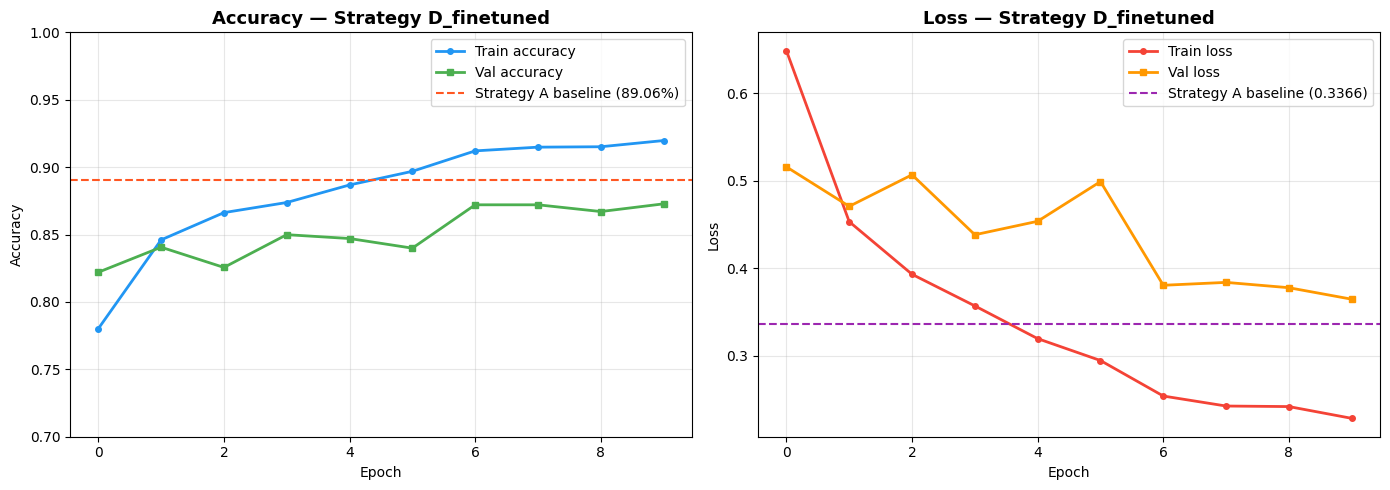


📊 Strategy D_finetuned Summary:
   Best Train Accuracy : 91.97%
   Best Val Accuracy   : 87.28%
   Final Train Loss    : 0.2285
   Final Val Loss      : 0.3646

   Strategy A baseline : 89.06% test accuracy


In [7]:
# ============================================================
# Cell 6 — Plot Fine-tuning Curves
#
# What to expect:
#   - Accuracy starts HIGH (~85-88%) and hopefully improves
#   - Loss starts LOW and keeps decreasing
#   - Dashed line shows Strategy A baseline for comparison
# Red flag: accuracy drops sharply in first 2 epochs → lr too high
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_ft.history['accuracy'],
             label='Train accuracy', color='#2196F3', linewidth=2, marker='o', markersize=4)
axes[0].plot(history_ft.history['val_accuracy'],
             label='Val accuracy',   color='#4CAF50', linewidth=2, marker='s', markersize=4)
axes[0].axhline(y=0.8906, color='#FF5722', linewidth=1.5,
                linestyle='--', label='Strategy A baseline (89.06%)')
axes[0].set_title(f'Accuracy — Strategy {STRATEGY}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.7, 1.0])   # zoom in — changes are small during fine-tuning

# Loss
axes[1].plot(history_ft.history['loss'],
             label='Train loss', color='#F44336', linewidth=2, marker='o', markersize=4)
axes[1].plot(history_ft.history['val_loss'],
             label='Val loss',   color='#FF9800', linewidth=2, marker='s', markersize=4)
axes[1].axhline(y=0.3366, color='#9C27B0', linewidth=1.5,
                linestyle='--', label='Strategy A baseline (0.3366)')
axes[1].set_title(f'Loss — Strategy {STRATEGY}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, f'finetuning_curves_{STRATEGY}.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Strategy {STRATEGY} Summary:")
print(f"   Best Train Accuracy : {max(history_ft.history['accuracy']):.2%}")
print(f"   Best Val Accuracy   : {max(history_ft.history['val_accuracy']):.2%}")
print(f"   Final Train Loss    : {history_ft.history['loss'][-1]:.4f}")
print(f"   Final Val Loss      : {history_ft.history['val_loss'][-1]:.4f}")
print(f"\n   Strategy A baseline : 89.06% test accuracy")

In [8]:
# ============================================================
# Cell 7 — Evaluate on Test Set & Per-class Analysis
#
# Key classes to watch:
#   Spider Mites  — was 77.3% (A), 89.3% (B) → should improve
#   Septoria      — was 85.3% (A), 90.7% (B) → should improve
#   Bacterial Spot — was 99.3% (A) → must NOT drop much
#   Leaf Mold      — was 92.3% (A) → must NOT drop much
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"🔄 Evaluating Strategy {STRATEGY} on test set...\n")

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\n{'='*50}")
print(f"📊 Strategy {STRATEGY} — Test Results")
print(f"{'='*50}")
print(f"✅ Test Accuracy : {test_accuracy:.2%}")
print(f"📉 Test Loss     : {test_loss:.4f}")
print(f"{'='*50}")

# Generate full predictions
print("\n🔄 Generating per-class predictions...")
test_generator.reset()
y_pred_proba = model.predict(test_generator, verbose=1)
y_pred  = np.argmax(y_pred_proba, axis=1)
y_true  = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(f"\n📋 Classification Report — Strategy {STRATEGY}\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# Per-class comparison: A vs B vs D
a_acc = [99.3, 82.0, 89.3, 92.3, 85.3, 77.3, 86.0, 95.3, 91.1, 94.0]
b_acc = [78.7, 74.7, 92.0, 79.0, 90.7, 89.3, 85.3, 96.7, 82.1, 90.0]

cm = confusion_matrix(y_true, y_pred)
d_acc = [cm[i, i] / cm[i].sum() * 100 for i in range(NUM_CLASSES)]

print("\n" + "─"*90)
print(f"{'Class':<45} {'A':>7} {'B':>7} {'D':>7}  {'D-A':>7}  {'D-B':>7}")
print("─"*90)
for i, cls in enumerate(class_names):
    diff_a = d_acc[i] - a_acc[i]
    diff_b = d_acc[i] - b_acc[i]
    flag_a = '🟢' if diff_a > 0 else '🔴'
    flag_b = '🟢' if diff_b > 0 else '🔴'
    print(f"{cls:<45} {a_acc[i]:>6.1f}% {b_acc[i]:>6.1f}% {d_acc[i]:>6.1f}%  "
          f"{flag_a}{diff_a:>+5.1f}%  {flag_b}{diff_b:>+5.1f}%")
print("─"*90)
print(f"{'OVERALL':<45} {'89.06%':>7} {'86.13%':>7} {test_accuracy:>6.2%}")

print(f"\n📈 All Strategies Comparison:")
print(f"  Strategy A (Color only)    : 89.06%")
print(f"  Strategy B (Segmented only): 86.13%")
print(f"  Strategy C (Mixed 50/50)   : 87.48%")
print(f"  Strategy D (Fine-tuned A)  : {test_accuracy:.2%}  ← new result")
print(f"\n  D vs A : {(test_accuracy - 0.8906)*100:+.2f}%")
print(f"  D vs B : {(test_accuracy - 0.8613)*100:+.2f}%")
print(f"  D vs C : {(test_accuracy - 0.8748)*100:+.2f}%")

🔄 Evaluating Strategy D_finetuned on test set...

44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 597ms/step - accuracy: 0.8842 - loss: 0.3688

📊 Strategy D_finetuned — Test Results
✅ Test Accuracy : 88.42%
📉 Test Loss     : 0.3688

🔄 Generating per-class predictions...
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 601ms/step

📋 Classification Report — Strategy D_finetuned

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot      0.893     0.887     0.890       150
                        Tomato___Early_blight      0.918     0.747     0.824       150
                         Tomato___Late_blight      0.926     0.913     0.919       150
                           Tomato___Leaf_Mold      0.917     0.923     0.920       143
                  Tomato___Septoria_leaf_spot      0.870     0.893     0.882       150
Tomato___Spider_mites Two-spotted_spider_mite      0.895     0.853     0.874       150
                         Tomato___Target_Spot

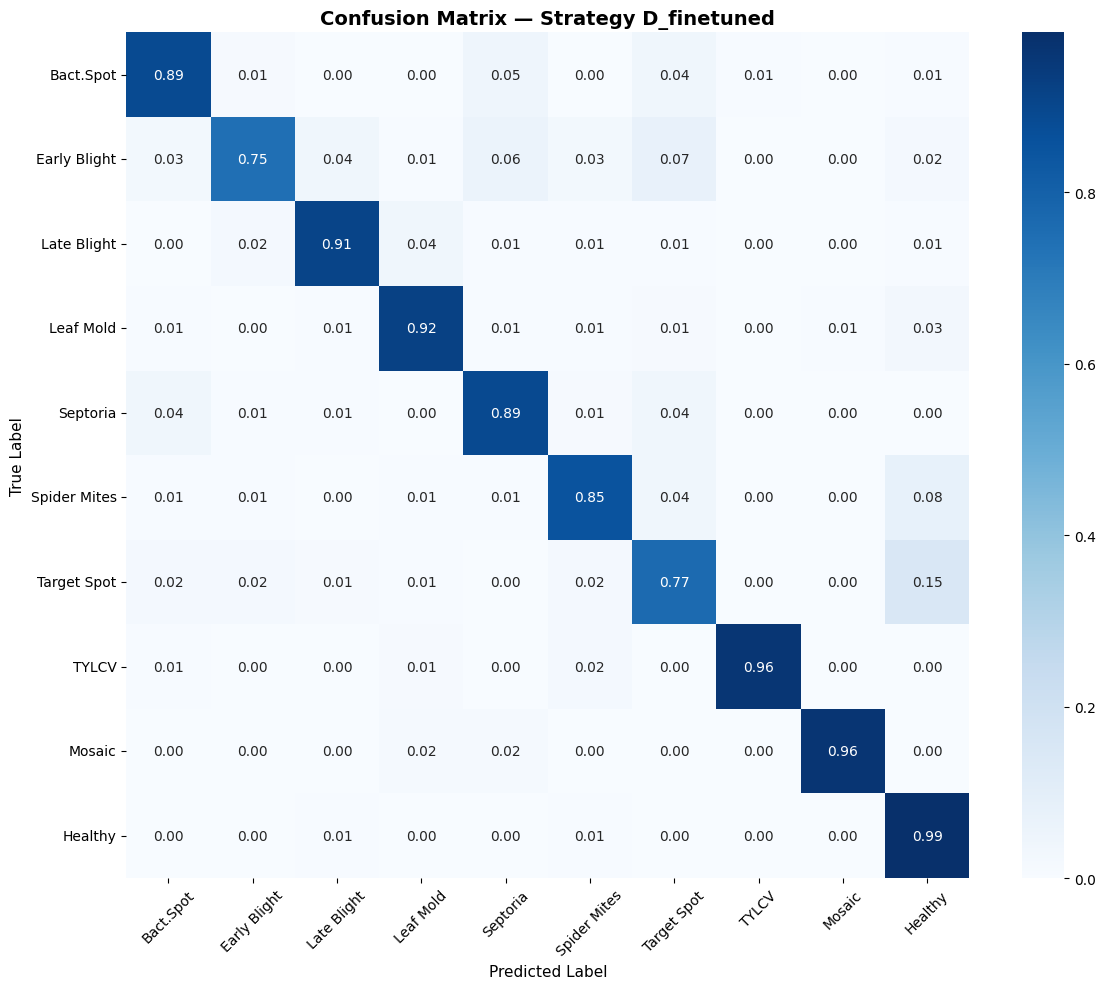

✅ Confusion matrix saved!


In [9]:
# ============================================================
# Cell 8 — Confusion Matrix
# ============================================================

short_names = [
    'Bact.Spot', 'Early Blight', 'Late Blight', 'Leaf Mold',
    'Septoria', 'Spider Mites', 'Target Spot', 'TYLCV',
    'Mosaic', 'Healthy'
]

fig, ax = plt.subplots(figsize=(12, 10))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names, ax=ax)
ax.set_title(f'Confusion Matrix — Strategy {STRATEGY}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, f'confusion_matrix_{STRATEGY}.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

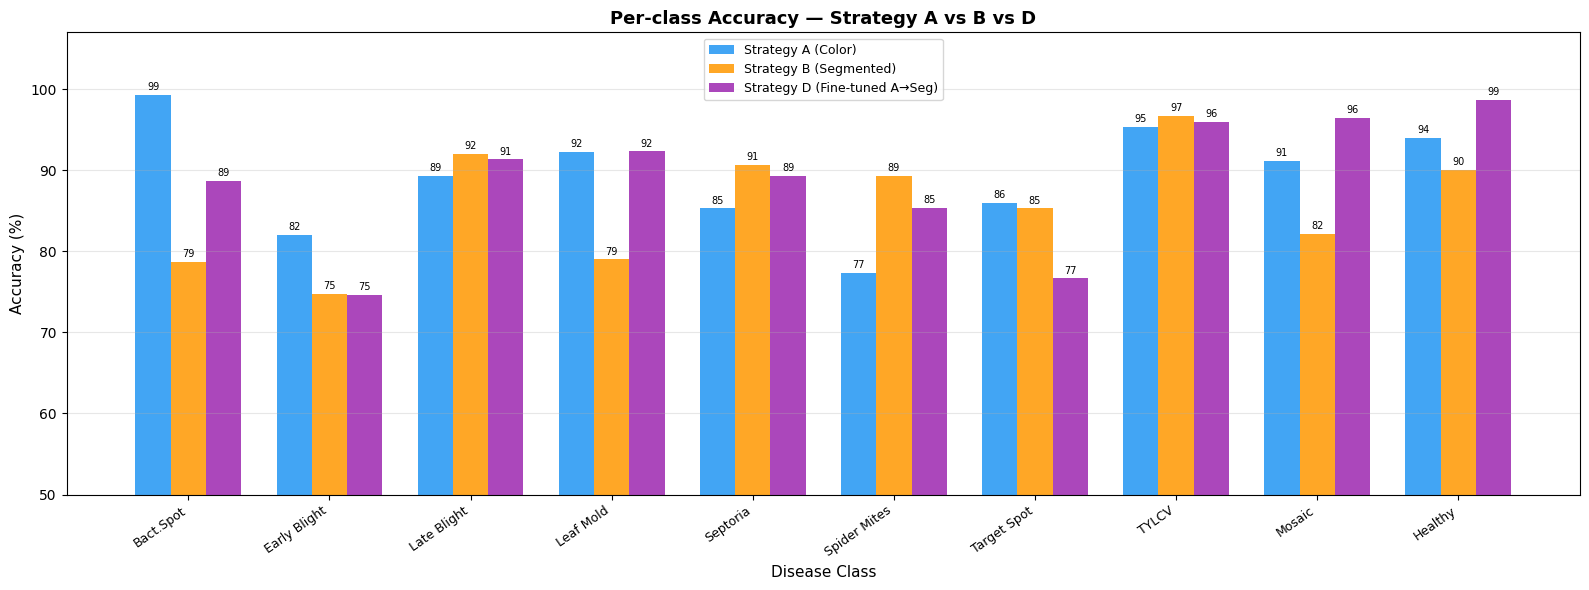

✅ Comparison chart saved!


In [10]:
# ============================================================
# Cell 9 — Per-class Accuracy Bar Chart (A vs B vs D)
# The main research chart for your paper — shows whether
# fine-tuning closed the gap on texture-dominant classes
# without hurting color-dominant ones.
# ============================================================

x     = np.arange(len(short_names))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))

bars_a = ax.bar(x - width, a_acc, width, label='Strategy A (Color)',            color='#2196F3', alpha=0.85)
bars_b = ax.bar(x,         b_acc, width, label='Strategy B (Segmented)',         color='#FF9800', alpha=0.85)
bars_d = ax.bar(x + width, d_acc, width, label='Strategy D (Fine-tuned A→Seg)',  color='#9C27B0', alpha=0.85)

ax.set_xlabel('Disease Class', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-class Accuracy — Strategy A vs B vs D', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=35, ha='right', fontsize=9)
ax.set_ylim([50, 107])
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Value labels on top of bars
for bars in [bars_a, bars_b, bars_d]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.0f}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 2), textcoords='offset points',
                    ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'comparison_A_vs_B_vs_D.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")

In [11]:
# ============================================================
# Cell 10 — Save Model & Log Results
# ============================================================

final_path   = os.path.join(MODEL_PATH,  f'model_{STRATEGY}_final.h5')
results_path = os.path.join(OUTPUT_PATH, 'results_summary.txt')

model.save(final_path)

with open(results_path, 'a') as f:
    f.write(f"\nStrategy {STRATEGY}\n")
    f.write(f"  Base model      : Strategy A (Color, 89.06%)\n")
    f.write(f"  Fine-tune data  : Segmented dataset\n")
    f.write(f"  Fine-tune lr    : {FINETUNE_LR}\n")
    f.write(f"  Fine-tune epochs: {FINETUNE_EPOCHS}\n")
    f.write(f"  Test Accuracy   : {test_accuracy:.4f}\n")
    f.write(f"  Test Loss       : {test_loss:.4f}\n")
    f.write(f"  Best Val Acc    : {max(history_ft.history['val_accuracy']):.4f}\n")
    f.write(f"  vs Strategy A   : {(test_accuracy - 0.8906)*100:+.2f}%\n")

print(f"✅ Final model saved  : {final_path}")
print(f"📝 Results logged to : {results_path}")

print(f"\n📁 Models folder now contains:")
for f in sorted(os.listdir(MODEL_PATH)):
    size = os.path.getsize(os.path.join(MODEL_PATH, f)) / (1024*1024)
    print(f"   {f} — {size:.1f} MB")

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Strategy D complete!
  Next step: build Strategy E (class-aware routing)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

✅ Final model saved  : D:\Development\8th Sem Project\TomatoClassification\models\model_D_finetuned_final.h5
📝 Results logged to : D:\Development\8th Sem Project\TomatoClassification\outputs\results_summary.txt

📁 Models folder now contains:
   best_model.h5 — 11.0 MB
   best_model_B_segmented.h5 — 11.0 MB
   best_model_C_Mixed.h5 — 11.0 MB
   best_model_D_finetuned.h5 — 22.6 MB
   model_B_segmented_final.h5 — 11.0 MB
   model_C_Mixed_final.h5 — 11.0 MB
   model_D_finetuned_final.h5 — 22.6 MB
   tomato_classifier_final.h5 — 11.0 MB

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Strategy D complete!
  Next step: build Strategy E (class-aware routing)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

